# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 2, March 4th, 2025

## 1) Uncertainties

A semiconductor is a material that conducts electricity more or less well depending on the temperature. In this experiment, you want to measure the so-called band-gap energy as a function of temperature of a semi-conductor, i.e. the amount of energy required to move an electron from the valence band to the conduction band. You can measure the tension $V$ and the current intensity $I$ of the electrical current going through the semi-conductor. Use the following formulas and the following measurement values to compute the resistance and band-gap energy with the correct propagated uncertainties.   

Plot the resistance and the band-gap energy as a function of temperature with the errorbars.

$$ R = V/I$$
$$E_\text{gap} \propto 2k_B T\ln R$$
with $k_B = 8.617333262145\cdot 10^{-5}$ ev/K

In [6]:
import numpy as np
import pandas as pd
from scipy.constants import zero_Celsius

T = np.arange(20., 610., 10.) + zero_Celsius 

V = np.array([1.67, 1.7,  1.74, 1.77, 1.79, 1.8, 1.82, 1.82, 1.81, 1.75, 1.65, 1.54, 1.41, 1.33, 1.28, 1.14, 1.02, 0.9, 0.79, 0.69, 0.6, 0.53, 0.47, 0.41, 0.37, 0.33, 0.3, 0.28, 0.26, 0.24, 0.22, 0.2, 0.19, 0.18, 0.16, 
              0.15, 0.14, 0.14, 0.13, 0.12, 0.11, 0.11, 0.1, 0.1, 0.09, 0.09, 0.09, 0.08, 0.08, 0.07, 0.07, 0.07, 0.07, 0.06, 0.06, 0.06, 0.06, 0.05, 0.05]) 

I = np.array([0.5433, 0.5552, 0.5122, 0.4744, 0.4443, 0.4202, 0.4071, 0.4172, 0.4755, 0.625, 0.896, 1.2977, 1.82, 2.35, 2.89, 3.68, 4.5, 5.45, 6.52, 7.7, 8.74, 9.88, 10.45, 12., 13.43, 14.75, 16.,      
                18.4, 20.6, 22.74, 24.96, 27.33, 29.75, 32.33, 35.03, 37.83, 40.74, 45.96, 48.21, 52.01, 55.97, 60.38, 64.84, 69.74, 74.74, 79.94, 85.4, 91.32, 96.34, 102.55, 109.46, 117.16, 123.76,  
                131.9, 138.08, 145.23, 153.9, 160.15, 167.81])/1000 

data = {
    'temperature': T,
    'tension': V,
    'intensity': I,
}

#uncertainties of the measurements
V_u = 0.01
I_u = 10e-5
T_u = 0.5

$$\Delta R = \sqrt{\bigg(\frac{\Delta V}{I}\bigg)^2 + \bigg(\frac{-V}{I^2}\Delta I\bigg)^2}$$

$$\Delta E = \sqrt{\bigg(2k_B\ln R \ \Delta  T\bigg)^2 + \bigg(\frac{2k_BT}{R}\Delta R\bigg)^2}$$

In [3]:
R = V/I
R_u = np.sqrt((V_u/I)**2 + (-V/I**2*I_u)**2)

from scipy.constants import physical_constants
k = physical_constants['Boltzmann constant in eV/K'][0]
E = 2*k*T*np.log(R)
E_u = np.sqrt((2*k*np.log(R)*T_u)**2 + (2*k*T/R*R_u)**2)

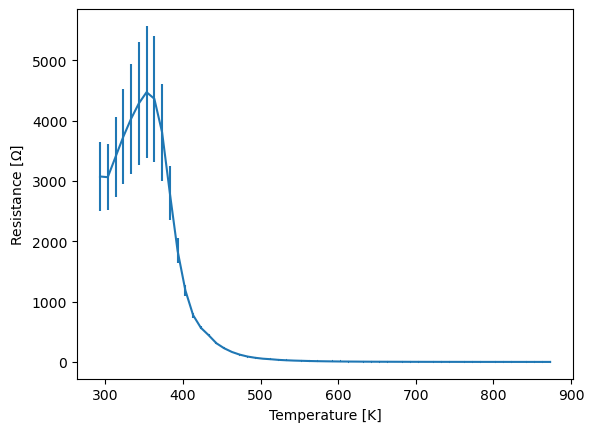

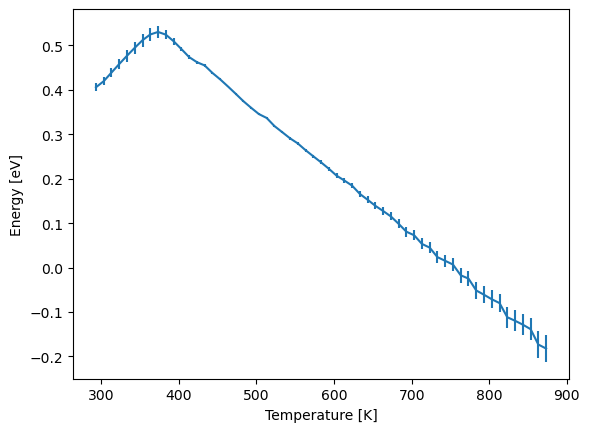

In [4]:
import matplotlib.pyplot as plt

plt.errorbar(T, R, xerr = T_u, yerr=R_u)
plt.xlabel('Temperature [K]')
plt.ylabel('Resistance [$\Omega$]')
plt.show()

plt.errorbar(T, E, xerr= T_u, yerr=E_u)
plt.xlabel('Temperature [K]')
plt.ylabel('Energy [eV]')
plt.show()

## 2) Covariances and correlations

Assume an experiment where you measure the energy, momentum, temperature and mass of a particle.   
Assess the pairwise correlations of these properties. 

In [7]:
import numpy as np
import pandas as pd

E = np.array([1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
p = np.array([0.5, 0.8, 1.0, 1.2, 1.4, 1.5, 1.8, 2.0])
t = np.array([300, 320, 330, 310, 325, 335, 340, 315])
m = np.array([0.5, 0.6, 0.7, 0.6, 0.8, 0.7, 0.75, 0.65])


data = {
    'energy': E,
    'momentum': p,
    'temperature': t,
    'mass': m,
}

df = pd.DataFrame(data)
df

,energy,momentum,temperature,mass
0,1.5,0.5,300,0.50
1,2.0,0.8,320,0.60
2,2.5,1.0,330,0.70
3,3.0,1.2,310,0.60
4,3.5,1.4,325,0.80
5,4.0,1.5,335,0.70
6,4.5,1.8,340,0.75
7,5.0,2.0,315,0.65


### 2.1) 
Compute the covariance and correlation factor of the parameters. 

In [8]:
cov = df.cov()
corr = df.corr()

print('Covariance matrix is: \n', cov)
print('\n\n Correlation matrix: \n', corr)

Covariance matrix is: 
                energy  momentum  temperature      mass
energy       1.500000  0.614286     8.392857  0.071429
momentum     0.614286  0.253571     3.482143  0.030357
temperature  8.392857  3.482143   178.125000  1.044643
mass         0.071429  0.030357     1.044643  0.009107


 Correlation matrix: 
                energy  momentum  temperature      mass
energy       1.000000  0.996035     0.513454  0.611132
momentum     0.996035  1.000000     0.518124  0.631713
temperature  0.513454  0.518124     1.000000  0.820190
mass         0.611132  0.631713     0.820190  1.000000


### 2.2)
Fill the energy and momentum into a 2D histogram with 5 bins on each axis, get the correlation and the covariance from the histogram and compare it with the calculated one. The difference with respect to (2.1) is that here your data are binned. Comment on the information loss from unbinned to binned data for the calculation of covariance/correlation and discuss the limit for which unbinned and binned data reach the same result. Note: getting correlation and covariance from the histogram means computing these quantities using the average values of the bins.

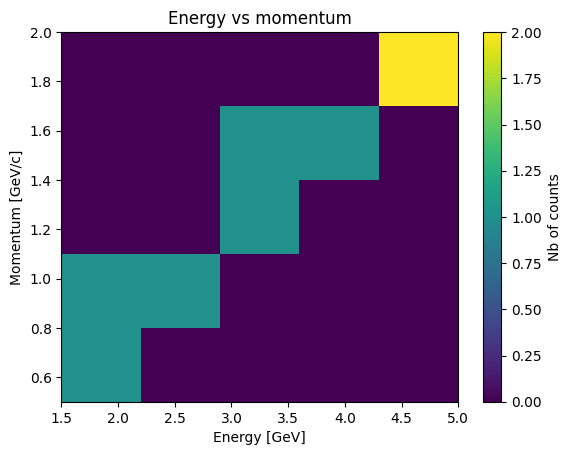

In [23]:
import matplotlib.pyplot as plt

h, xedges, yedges, img = plt.hist2d(E, p, bins = 5)
plt.xlabel('Energy [GeV]')
plt.ylabel('Momentum [GeV/c]')
plt.title('Energy vs momentum')
plt.colorbar(img, label = 'Nb of counts')
plt.show()

In [25]:
E_bin_avg = 0.5 * (yedges[1:] + yedges[:-1])
p_bin_avg = 0.5 * (xedges[1:] + xedges[:-1])

E_bin = []
p_bin = []

for index, count in np.ndenumerate(h):
    for i in range(int(count)):
        E_bin.append(E_bin_avg[index[1]])
        p_bin.append(p_bin_avg[index[0]])

cov_bin = np.cov(E_bin, p_bin)[0,1]
corr_bin = np.corrcoef(E_bin, p_bin)[0,1]

print('Covariance from the binned data: %.5f, compared to %.5f for unbinned data' % (cov_bin, cov['momentum']['energy']))
print('Correlation from the binned data: %.5f, compared to %.5f for unbinned data' % (corr_bin, corr['momentum']['energy']))

Covariance from the binned data: 0.48000, compared to 0.61429 for unbinned data
Correlation from the binned data: 0.95789, compared to 0.99604 for unbinned data


## 3) Monte Carlo integration

Write a function to compute the following integral:
$$I = \int_0^\pi \sin(x) dx.$$
Try with different number of steps and plot the error as a function of $N$.

1. use a MC method of your choice
2. use a "raindrop in bucket" MC method

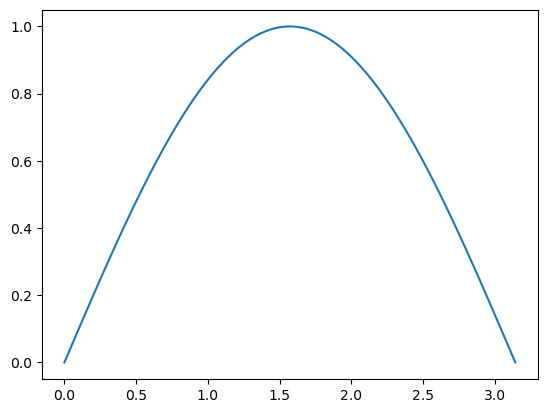

In [9]:
points = np.linspace(0, np.pi, 100)
plt.plot(points, np.sin(points))

In [26]:
def MC_integration(f, a, b, N):
    x = np.random.uniform(a, b, N)
    y = f(x)
    y_bar = np.mean(y)
    I = (b-a)*y_bar

    return I

In [37]:
n = np.array([10, 100, 1000, 10e4, 10e5], dtype = int)

MC = []

for i in n:
    MC.append(MC_integration(lambda x: np.sin(x), 0, np.pi, i))

MC_err = np.abs(np.array(MC) - 2)
print(MC)

[2.084739975079073, 1.9039639027174613, 2.0026992234665633, 1.992675880198115, 2.0017547850414794]


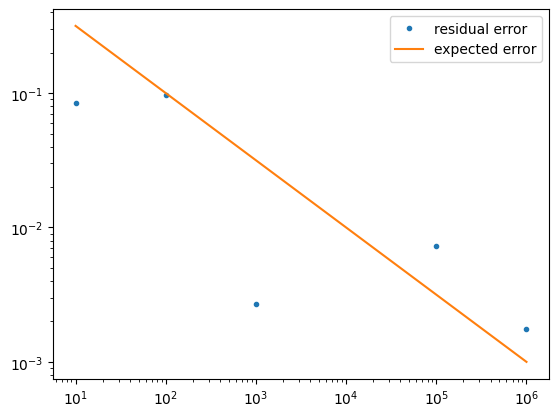

In [43]:
plt.loglog(n, MC_err, '.', label='residual error')
plt.loglog(n, 1/np.sqrt(n), label='expected error')
plt.legend(loc = 'best')

Samples:          1  |  Integral:       3.1416  |  Uncertainty:       1.0000
Samples:         10  |  Integral:       2.5133  |  Uncertainty:       0.2530
Samples:        100  |  Integral:       2.2305  |  Uncertainty:       0.0710
Samples:      1,000  |  Integral:       1.9729  |  Uncertainty:       0.0199
Samples:     10,000  |  Integral:       2.0075  |  Uncertainty:       0.0064
Samples:    100,000  |  Integral:       2.0024  |  Uncertainty:       0.0020
Samples:  1,000,000  |  Integral:       2.0032  |  Uncertainty:       0.0006


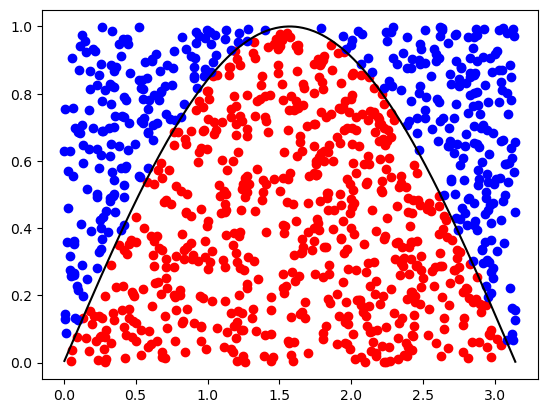

In [43]:
def MC_integration_alt(func, xmin, xmax, ymin, ymax, N, plotting=False):
    
    x = np.random.uniform(xmin, xmax, int(N))
    y = np.random.uniform(ymin, ymax, int(N))
    
    below_the_curve = y < func(x)
    above_the_curve = ~below_the_curve
    
    integral = (np.sum(below_the_curve) / N) * (xmax - xmin) * (ymax - ymin)
    # binomial uncertainty, epsilon * (1-epsilon) / N, see script!!!
    uncertainty = np.sqrt( (np.sum(below_the_curve)/N * (1-np.sum(above_the_curve)/N)) / N)
    
    if plotting:
        plt.scatter(x[below_the_curve], y[below_the_curve], color='r')
        plt.scatter(x[above_the_curve], y[above_the_curve], color='b')
        plt.plot(sorted(x), func(sorted(x)), color='black')
        plt.show()

    return integral, uncertainty

func = lambda x: np.sin(x) 

for N in np.logspace(0, 6, 7):
    integral, uncertainty = MC_integration_alt(func, 0, np.pi, 0, 1, N)
    print(f'Samples: {N:>10,.0f}  |  Integral: {integral:>12.4f}  |  Uncertainty: {uncertainty:>12.4f}')

# plot one example with 1000
integral, uncertainty = MC_integration_alt(func, 0, np.pi, 0, 1, 1000, True)

## 3b) Importance sampling

Now we want to integrate numerically the function: 

$$I = \int_{0}^{2} e^{-x^2/2} \sin^2(5x) dx.$$.

Do it with different methods and compare the uncertainty of the result depending of the number of samples used for the integration. 

In particular, test 2 different functions used to propose candidate samples for the integration with **importance sampling**:
- a "bad" function, having a different shape (e.g. a uniform distribution)
- a good function, having a similar shape as the integrand


Which function gives you the best integration uncertainty? Does the integral converges in both cases or not?

In [168]:
def f(x):
    return np.exp(-x**2/2)*(np.sin(5*x))**2

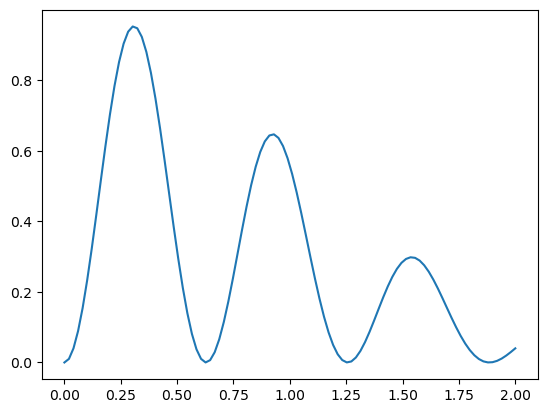

In [195]:
points = np.linspace(0,2, 100)
plt.plot(points, f(points))

### Integral with the sampling methods. 

In [137]:
def get_integral(samples, prob_samples):
    w = f(samples)/prob_samples
    return np.mean(w), np.std(w)/np.sqrt(len(samples))

In [179]:
u = np.random.uniform(0, 2, 100000)
sampling_prob = np.ones(u.shape)*1/2.
integral, integral_err = get_integral(u, sampling_prob)
print(f"Integral: {integral:.5f} +- {integral_err:.5f} ({integral_err*100/ integral:.3f}%)")

Integral: 0.59184 +- 0.00176 (0.297%)


### Integral with the importance sampling

We can use a $exp(-x)$ function to generate sample for the integral as a "good" sampling function. 
In order to sample points distributed as exp(-x) we need to have the inverse of the cumulative distribution function of f(x). 

**N.B.:** We need a properly normalized p.d.f. to compute the importance sampling, we need to normalize $e^{-x}$ between 0 and 2. 


$$CDF(x) = \int_{0}^x  A e^{-x} =  A(1 - e^{-x})  $$
$$CDF^{-1}(y) = - log(1-\frac{y}{A})$$ 
$$ 1 = \int_0^2 A e^{-x} = A(1 - e^{-2}) = 1 \rightarrow  A = 1 / (1- e^{-2})$$ 

We can then sample uniformly between $[0,1]$ and use the inverse of the cumulative function to obtain samples distributed as exp(-x).

In [202]:
def generate_samples_exp(N_samples):
    y = np.random.uniform(size=(N_samples))
    return - np.log(1-y*(1- np.exp(-2)))

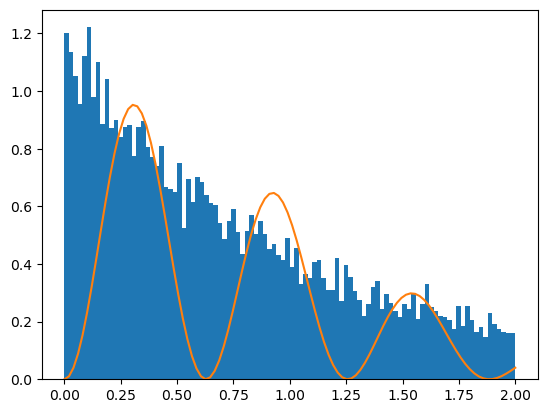

In [198]:
samples = generate_samples_exp(10000)
prob_samples = (1/(1 - np.exp(-2)))* np.exp(-samples)
plt.hist(samples, bins=100, density=True);
points = np.linspace(0,2, 100)
plt.plot(points, f(points))

In [199]:
# We need to mask samples in the integration domain
mask = samples<2
integral, integral_err = get_integral(samples[mask], prob_samples[mask])
print(f"Integral: {integral:.5f} +- {integral_err:.5f} ({integral_err*100/ integral:.3f}%)")

Integral: 0.59380 +- 0.00448 (0.754%)


We can now check the behaviour of the integration for an increasing number of samples in the two cases./

In [207]:
results = [] 
results_impsampl = [] 
stds = [ ]
stds_impsampl = []
for N in np.logspace(2, 7, 30):
    u = np.random.uniform(0, 2, int(N))
    sampling_prob = np.ones(u.shape)*1/2.
    integral_uniform, integral_err_uniform = get_integral(u, sampling_prob)
    results.append(integral_uniform)
    stds.append(integral_err_uniform)

    samples = generate_samples_exp(int(N))
    prob_samples = (1/(1 - np.exp(-2)))* np.exp(-samples)
    mask = samples<2
    integral_impsampl, integral_err_impsampl = get_integral(samples[mask], prob_samples[mask])
    results_impsampl.append(integral_impsampl)
    stds_impsampl.append(integral_err_impsampl)

Text(0, 0.5, 'Integral')

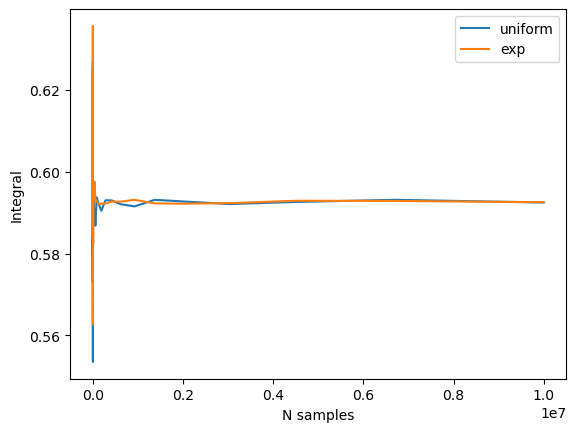

In [212]:
x = np.logspace(2, 7, 30)
plt.plot(x, results, label="uniform")
plt.plot(x, results_impsampl, label="exp")
plt.legend()
plt.xlabel("N samples")
plt.ylabel("Integral")

Text(0, 0.5, 'Err. integral')

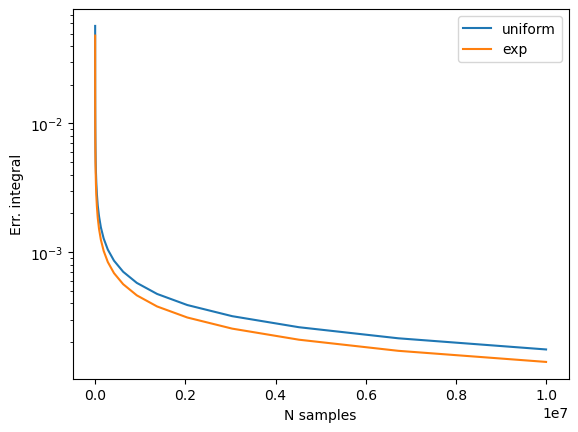

In [213]:
x = np.logspace(2, 7, 30)
plt.plot(x, stds, label="uniform")
plt.plot(x, stds_impsampl, label="exp")
plt.legend()
plt.yscale("log")
plt.xlabel("N samples")
plt.ylabel("Err. integral")